## Notebook to be converted to a script to run tests of mpasregions package

for a periodic boundary, if you need to go across an entire latitude, the sorting algorithm should divide the transect into upper and lower

need to run tests for using a mask created from a goejson file to start with

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mpas_tools

from geometric_features import GeometricFeatures
from geometric_features import read_feature_collection

from mpas_tools.mesh.mask import compute_mpas_region_masks
from mpas_tools.parallel import create_pool
from mpas_tools.io import write_netcdf

import geojson
import json
import mosaic
import os.path
import mpasregions.sections as mps
import gsw
import warnings 
import glob
from xgcm import Grid

In [3]:
# load sample dataset
mesh_path = '/global/cfs/projectdirs/e3sm/inputdata/ocn/mpas-o/EC30to60E2r2/ocean.EC30to60E2r2.210210.nc'
mesh = xr.open_dataset(mesh_path)
mesh = mesh.assign_coords({
"VertexID": xr.DataArray(mesh.indexToVertexID, dims=('nVertices',)),
})

# global data
bmm_filepath = '/pscratch/sd/b/bmoorema/run_001_062/'
dso = xr.open_dataset(bmm_filepath + '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStatsMonthly.0063-12-01.nc')

/tmp/ipykernel_776452/3081353271.py:10: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dso = xr.open_dataset(bmm_filepath + '20210421_sim7_CORE_60to30E2r2.mpaso.hist.am.timeSeriesStatsMonthly.0063-12-01.nc')


### create dataset

In [4]:
# I actually think that you will need to somehow define cells to be nans to represent land (or at least for cellsOnEdge)... 

lonCells = np.array([180.,  90., 270.])
latCells = np.array([-36.,  36.,  36.])

lonEdges = np.array([135., 235.,  90., 270.,  45., 135., 225., 315.,   0., 180., 45., 135., 225., 315.])
latEdges = np.array([-72., -72., -36., -36.,   0.,   0.,   0.,   0.,  36.,  36., 72.,  72.,  72.,  72.])

lonVertices = np.array([180.,  90., 270.,  90., 270.,   0., 180.,   0., 180., 90., 270.])
latVertices = np.array([-90., -54., -54., -18., -18.,  18.,  18.,  54.,  54., 90.,  90.])

ds = xr.Dataset({},coords={
    'nCells':xr.DataArray(np.arange(0,len(lonCells)), dims='nCells'),
    'nEdges': xr.DataArray(np.arange(0,len(lonEdges)), dims='nEdges'),
    'nVertices':xr.DataArray(np.arange(0,len(lonVertices)), dims='nVertices')
})

ds['lonCell'] = xr.DataArray(np.deg2rad(lonCells), dims='nCells')
ds['latCell'] = xr.DataArray(np.deg2rad(latCells), dims='nCells')
ds['lonEdge'] = xr.DataArray(np.deg2rad(lonEdges), dims='nEdges')
ds['latEdge'] = xr.DataArray(np.deg2rad(latEdges), dims='nEdges')
ds['lonVertex'] = xr.DataArray(np.deg2rad(lonVertices), dims='nVertices')
ds['latVertex'] = xr.DataArray(np.deg2rad(latVertices), dims='nVertices')

xr_edgesOnVertex =  np.array([
    [0,1,np.nan], # on vertex 0
    [0,2,np.nan], # on vertex 1
    [1,3,np.nan], # on vertex 2
    [2,4,5], # on vertex 3
    [3,6,7], # on vertex 4
    [4,7,8], # on vertex 5
    [5,6,9], # on vertex 6
    [8,10,13], # on vertex 7
    [9,11,12], # on vertex 8
    [10,11,np.nan], # on vertex 9
    [12,13,np.nan] # on vertex 10
])

n_edgesOnVertex = mps.xr_to_n_idx(xr_edgesOnVertex)
n_edgesOnVertex[np.isnan(n_edgesOnVertex)] = 0 # extra vertices that were once nans are now zeros

ds['edgesOnVertex'] = xr.DataArray(np.int32(n_edgesOnVertex), dims = ('nVertices','vertexDegree'))
# ds['edgesOnVertex'] = ds.edgesOnVertex.where(ds.edgesOnVertex > 0)
# ds.edgesOnVertex

xr_verticesOnEdge = np.array([
    [0,1], # on edge 0
    [0,2], # on edge 1
    [1,3], # on edge 2
    [2,4], # on edge 3
    [3,5], # on edge 4
    [3,6], # on edge 5
    [4,6], # on edge 6
    [4,5], # on edge 7
    [5,7], # on edge 8
    [6,8], # on edge 9
    [7,9], # on edge 10
    [8,9], # on edge 11
    [8,10], # on edge 12
    [7,10] # on edge 13
    
])

n_verticesOnEdge = mps.xr_to_n_idx(xr_verticesOnEdge)
ds['verticesOnEdge'] = xr.DataArray(np.int32(n_verticesOnEdge), dims=('nEdges', 'TWO'))

xr_cellsOnEdge = np.array([
    [0,np.nan], # on edge 0
    [0,np.nan], # on edge 1
    [0,np.nan], # on edge 2
    [0,np.nan], # on edge 3
    [1,np.nan], # on edge 4
    [0,1],  # on edge 5
    [0,2],  # on edge 6
    [2,np.nan], # on edge 7
    [1,2],  # on edge 8
    [1,2],  # on edge 9
    [1,np.nan], # on edge 10
    [1,np.nan], # on edge 11
    [2,np.nan], # on edge 12
    [2,np.nan] #on edge 13
])

n_cellsOnEdge = mps.xr_to_n_idx(xr_cellsOnEdge)
n_cellsOnEdge[np.isnan(n_cellsOnEdge)] = 0
ds['cellsOnEdge'] = xr.DataArray(np.int32(n_cellsOnEdge), dims=('nEdges', 'TWO'))

xr_verticesOnCell = np.array([
                    [0,1,3,6,4,2,np.nan], # on cell 0
                    [3,5,7,9,8,6,np.nan], # on cell 1
                    [4,6,8,10,7,5,np.nan] # on cell 2
])

n_verticesOnCell = mps.xr_to_n_idx(xr_verticesOnCell)
n_verticesOnCell[np.isnan(n_verticesOnCell)] = 0
ds['verticesOnCell'] = xr.DataArray(np.int32(n_verticesOnCell), dims=('nCells','maxEdges'))

xr_edgesOnCell = np.array([
                [0,2,5,6,3,1,np.nan], # on cell 0
                [4,8,10,11,9,5,np.nan], # on cell 1
                [6,9,12,13,8,7,np.nan] # on cell 2
])

n_edgesOnCell = mps.xr_to_n_idx(xr_edgesOnCell)
n_edgesOnCell[np.isnan(n_edgesOnCell)] = 0
ds['edgesOnCell'] = xr.DataArray(np.int32(n_edgesOnCell), dims=('nCells','maxEdges'))

# I cannot remember if the 3-layer set-up was appropriate enough for set-up for testing transport/convergent fluxes
# 0 thickness is like a nan. represents a land cell.
xr_layerThickness = np.array([
                    [1, 1, 0], # cell 0. 1 at surface, 0 at bottom
                    [0.5,0,0], # cell 1. 0.5 at surface, 0 at bottom
                    [1, 1, 0] # cell 2. 1 at surface, 0 at bottom
])

ds['timeMonthly_avg_layerThickness'] = xr.DataArray(xr_layerThickness, dims=('nCells','nVertLevels'))

# add time
ds['xtime_startMonthly'] = xr.DataArray(np.array([b'0063-12-01_00:30:00'], dtype='|S64'), dims='Time')
ds = ds.swap_dims({'Time':'xtime_startMonthly'})

# add normal velocity
xr_normalVelocity = np.array([[
    [0,0,0], # on edge 0. 0 for all levels
    [0,0,0], # on edge 1. 0 for all levels
    [0,0,0], # on edge 2. 0 for all levels
    [0,0,0], # on edge 3. 0 for all levels
    [0,0,0], # on edge 4. 0 for all levels
    [-1,0,0], # on edge 5. from cell 1 (B) to cell 0 (A) at surface.
    [0.75,0.5,0], # on edge 6. from cell 0 (A) to cell (B) at surface (0.75) and level 2 (0.5)
    [0,0,0], # on edge 7. 0 for all levels
    [-1,0,0], # on edge 8. from cell 2 (B) to cell 1 (A) at surface
    [0,0,0], # on edge 9. 0 for all levels
    [0,0,0], # on edge 10. 0 for all levels
    [0,0,0], # on edge 11. 0 for all levels
    [0,0,0], # on edge 12. 0 for all levels
    [0,0,0] # on edge 13. 0 for all levels.
]])

ds['timeMonthly_avg_normalVelocity'] = xr.DataArray(xr_normalVelocity, dims=('xtime_startMonthly','nEdges','nVertLevels'))

# add dvEdge (calculated as the distance between vertices)
dvEdge = np.array([188079.69356148, 188079.69356148,  69865.8329326 ,  69865.8329326 ,
       188118.69974708, 188118.69974708, 188118.69974708, 528628.34731413,
        69865.8329326 ,  69865.8329326 , 188079.69356148, 188079.69356148,
       188079.69356148, 528503.3555391 ])

ds['dvEdge'] = xr.DataArray(dvEdge, dims=('nEdges'))

ds['VertexID'] = mps.xr_to_n_idx(ds.nVertices)
ds = ds.assign_coords({'VertexID': mps.xr_to_n_idx(ds.nVertices)})

In [5]:
ds.dvEdge

<xarray.DataArray 'dvEdge' (nEdges: 14)> Size: 112B
array([188079.69356148, 188079.69356148,  69865.8329326 ,  69865.8329326 ,
       188118.69974708, 188118.69974708, 188118.69974708, 528628.34731413,
        69865.8329326 ,  69865.8329326 , 188079.69356148, 188079.69356148,
       188079.69356148, 528503.3555391 ])
Coordinates:
  * nEdges   (nEdges) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13

In [6]:
# a one-time use of distance_on_sphere to calculate dvEdge 
def distance_on_unit_sphere(lon1, lat1, lon2, lat2, R=6.371e6, method="vincenty"):
    """
    Calculate geodesic arc distance between points (lon1, lat1) and (lon2, lat2).

    PARAMETERS:
    -----------
        lon1 : float
            Start longitude(s), in degrees
        lat1 : float
            Start latitude(s), in degrees
        lon2 : float
            End longitude(s), in degrees
        lat2 : float
            End latitude(s), in degrees
        R : float
            Radius of sphere. Default: 6.371e6 (realistic Earth value). Set to 1 for
            arc distance in radius.
        method : str
            Name of method. Supported methods: ["vincenty", "haversine", "law of cosines"].
            Default: "vincenty", which is the most robust. Note, however, that it still can result in
            vanishingly small (but crucially non-zero) errors; such as that the distance between (0., 0.)
            and (360., 0.) is 1.e-16 meters when it should be identically zero.

    RETURNS:
    --------

    dist : float
        Geodesic distance between points (lon1, lat1) and (lon2, lat2).
    """
    
    phi1 = np.deg2rad(lat1)
    phi2 = np.deg2rad(lat2)
    dphi = np.abs(phi2-phi1)
    
    lam1 = np.deg2rad(lon1)
    lam2 = np.deg2rad(lon2)
    dlam = np.abs(lam2-lam1)
    
    if method=="vincenty":
        numerator = np.sqrt(
            (np.cos(phi2)*np.sin(dlam))**2 +
            (np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlam))**2
        )
        denominator = np.sin(phi1)*np.sin(phi2) + np.cos(phi1)*np.cos(phi2)*np.cos(dlam)
        arc = np.arctan2(numerator, denominator)
        
    elif method=="haversine":
        arc = 2*np.arcsin(np.sqrt(
            np.sin(dphi/2.)**2 + (1. - np.sin(dphi/2.)**2 - np.sin((phi1+phi2)/2.)**2)*np.sin(dlam/2.)**2
        ))
    
        
    elif method=="law of cosines":
        arc = np.arccos(
            np.sin(phi1)*np.sin(phi2) + np.cos(phi1)*np.cos(phi2)*np.cos(dlam)
        )

    return R * arc

In [7]:
dvEdge_array = np.array([])
for i in range(0,len(ds.nEdges)):
    # choose vertices in xr coords
    xr_vertexA = (ds.verticesOnEdge.isel(nEdges = i) - 1)[0]
    xr_vertexB = (ds.verticesOnEdge.isel(nEdges = i) - 1)[1]

    # find the latitude and longitudes of the vertices
    xr_latVertexA = ds.latVertex.isel(nVertices = xr_vertexA)
    xr_lonVertexA = ds.lonVertex.isel(nVertices = xr_vertexA)

    xr_latVertexB = ds.latVertex.isel(nVertices = xr_vertexB)
    xr_lonVertexB = ds.lonVertex.isel(nVertices = xr_vertexB)

    # calculate the distance between vertexA and vertexB
    distance = distance_on_unit_sphere(xr_lonVertexA, xr_latVertexA, xr_lonVertexB, xr_latVertexB, R=6.371e6, method="vincenty")

    # add that to the edge distance array
    dvEdge_array = np.append(dvEdge_array, distance)

In [8]:
dvEdge_array

array([188079.69356148, 188079.69356148,  69865.8329326 ,  69865.8329326 ,
       188118.69974708, 188118.69974708, 188118.69974708, 528628.34731413,
        69865.8329326 ,  69865.8329326 , 188079.69356148, 188079.69356148,
       188079.69356148, 528503.3555391 ])

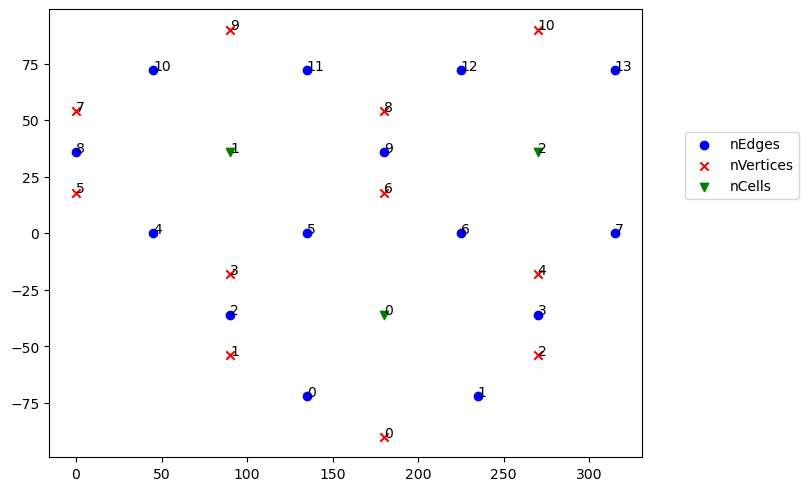

In [9]:
fig,ax=plt.subplots(nrows=1,ncols=1,constrained_layout=True)
ax.scatter(np.rad2deg(ds.lonEdge),np.rad2deg(ds.latEdge),color='blue',label='nEdges')
ax.scatter(np.rad2deg(ds.lonVertex),np.rad2deg(ds.latVertex),marker='x',color='red',label='nVertices')
ax.scatter(np.rad2deg(ds.lonCell), np.rad2deg(ds.latCell),marker='v',color='green',label='nCells')
nEdges = ds.nEdges.values
nVertices = ds.nVertices.values
nCells = ds.nCells.values

for i, txt in enumerate(nEdges):
    ax.annotate(txt, (np.rad2deg(ds.lonEdge[i]),np.rad2deg(ds.latEdge[i])))

for i, txt in enumerate(nVertices):
    ax.annotate(txt, (np.rad2deg(ds.lonVertex[i]), np.rad2deg(ds.latVertex[i])))

for i, txt in enumerate(nCells):
    ax.annotate(txt, (np.rad2deg(ds.lonCell[i]), np.rad2deg(ds.latCell[i])))

fig.legend(bbox_to_anchor=(1.25, 0.75))

# test transport creation, finding, sorting functions

### test transect calculation functions ```calculate_transect``` and ```calculate_transect_multiple_pts```

In [10]:
# **** TEST TRANSECT CALCULATION ALGORTHMS ****

def test_calculate_transects(ds):
    from mpasregions.sections import calculate_transects
    # test if basic algorithm works
    target_start_lon, target_start_lat = 90, -30
    target_end_lon, target_end_lat = 180, 60
    test_edges, test_vertices = calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds)
    assert (test_vertices == np.array([3,6,8])).all()
    assert(test_edges == np.array([5,9])).all()

    # test periodicity in x-direction
    target_start_lon, target_start_lat = 0, 18
    target_end_lon, target_end_lat = 270, 18
    test_edges, test_vertices = calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds)
    assert (test_vertices == np.array([5,4])).all()
    assert(test_edges == 7)

    # test periodicity in y-direction
        # the transect should move south to north (90,-54) does not connect to (90,54) directly.
    target_start_lon, target_start_lat = 90, -54
    target_end_lon, target_end_lat = 90, 90
    test_edges, test_vertices = calculate_transects(target_start_lat, target_start_lon, target_end_lat, target_end_lon, ds)
    assert(test_vertices == np.array([1,3,5,7,9])).all()
    assert(test_edges == np.array([2,4,8,10])).all()

def test_calculate_transects_multiple_pts(ds):
    from mpasregions.sections import calculate_transects_multiple_pts
    # calculate_transects_multiple_pts(segment_lons,segment_lats,ds)

    # test if basic algorithm works
    target_lons = np.array([90,90,180])
    target_lats = np.array([-18,90,18])
    test_edges, test_vertices = calculate_transects_multiple_pts(target_lons, target_lats, ds)
    assert(test_vertices == np.array([3,5,7,9,8,6])).all()
    assert(test_edges == np.array([4,8,10,11,9,5])).all()

    # test periodicity in x-direction
    target_lons = np.array([270,360,180]) 
    target_lats = np.array([0,0,0])
    test_edges, test_vertices = calculate_transects_multiple_pts(target_lons, target_lats, ds)
    assert(test_vertices == np.array([4,5,3,6])).all()
    assert(test_edges == np.array([7,4,5,6])).all()

    # test periodicity in y-direction
    target_lons = np.array([90,180,270])
    target_lats = np.array([-54,-90,90])
    test_edges, test_vertices = calculate_transects_multiple_pts(target_lons, target_lats, ds)
    assert(test_vertices == np.array([1,0,1,3,5,7,10,7,5,3])).all()

In [11]:

# # test if you can create a transect bounded by two lines of latitude that wrap around the entire globe
# this block does not exist (idk what to do about this transect yet), and we will pretend that this is fine
# compute_mpas_transect_masks???

# target_lons = np.array([270,180,90,0,90,180,270,0])
# target_lats = np.array([-18,18,-18,18,90,54,90,54])
# test_edges, test_vertices = mps.calculate_transects_multiple_pts(target_lons, target_lats, ds)

# test_vertices = np.array([ 4,  6,  3,  5,  7,  9,  8, 10,  7,  5])
# path = './'
# filename = 'test_latitude_boundaries'
# geojson_file_name = 'test if geojson file identifies all cells inside transect defined along (somewhat) lines of latitude'
# tags = 'unstructured_hexagonal_grid;test_latitude_boundaries_transect'
# author = 'Kaila Uyeda'
# geojson_vertexLats, geojson_vertexLons, dsMasks = mps.transect_from_alg_create_nc(test_vertices, ds, path, filename, geojson_file_name, tags, author)

In [12]:
test_calculate_transects(ds)

broken because reached end vertex
broken because reached end vertex
broken because reached end vertex


In [13]:
test_calculate_transects_multiple_pts(ds)

broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex
broken because reached end vertex


### test mask-creating function ```test_transect_from_alg_create_nc```

In [14]:
def test_transect_from_alg_create_nc(ds):
    from mpasregions.sections import transect_from_alg_create_nc
    
    # test basic algorithm
    test_vertices = np.array([3, 5, 7, 9, 8, 6])
    path = './'
    filename = 'test_basic_alg'
    geojson_file_name = 'basic test if transect_from_alg_create_nc works'
    tags = 'unstructured_hexagonal_grid;test_basic'
    author = 'Kaila Uyeda'
    geojson_vertexLats, geojson_vertexLons, dsMasks = transect_from_alg_create_nc(test_vertices, ds, path, filename, geojson_file_name, tags, author)
    assert(geojson_vertexLats == np.array([-18.,  18.,  54.,  90.,  54.,  18.])).all()
    assert(geojson_vertexLons == np.array([ 90.,   0.,   0.,  90., 180., 180.])).all()
           
    # test transects that cross over themselves
    # geojson file should maintain vertices and edges that are not connected to cells inside the desired region
    # mask that is created should only include cells inside the desired region
    test_vertices = np.array([9, 8, 6, 4, 6, 3, 5, 7])
    path = './'
    filename = 'test_crossing_transect'
    geojson_file_name = 'test if geojson file keeps vertices from transect'
    tags = 'unstructured_hexagonal_grid;test_crossing_transect'
    author = 'Kaila Uyeda'
    geojson_vertexLats, geojson_vertexLons, dsMasks = transect_from_alg_create_nc(test_vertices, ds, path, filename, geojson_file_name, tags, author)
    assert(geojson_vertexLats == np.array([ 90.,  54.,  18., -18.,  18., -18.,  18.,  54.])).all()
    assert(geojson_vertexLons == np.array([ 90., 180., 180., 270., 180.,  90.,   0.,   0.])).all()
    assert(dsMasks.isel(nRegions=0).regionCellMasks.values == np.array([0,1,0])).all()


In [15]:
test_transect_from_alg_create_nc(ds)

test_basic_alg_transect_from_alg.geojson exists!
Opening test_basic_alg_transect_from_alg.nc as dsMasks
test_crossing_transect_transect_from_alg.geojson exists!
Opening test_crossing_transect_transect_from_alg.nc as dsMasks


### test ```find_transect_edges_and_vertices``` function

In [16]:
def test_find_transect_edges_and_vertices(ds):
    from mpasregions.sections import find_transect_edges_and_vertices

    # test basic algorithm around a single cell
    # should return edges and vertices that surround that cell
    regionCellMasks_array = np.int32(np.array([[0],[1],[0]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    )) 
    xr_mask_transect_edges, xr_mask_transect_vertices = find_transect_edges_and_vertices(ds, ds_mask)
    assert(xr_mask_transect_edges == np.array([ 4,  5,  8,  9, 10, 11])).all()
    assert(xr_mask_transect_vertices == np.array([3, 5, 6, 7, 8, 9])).all()

    # test basic algorithm around multiple cells
    # edge between the two cells should not be included
    regionCellMasks_array = np.int32(np.array([[1],[1],[0]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    xr_mask_transect_edges, xr_mask_transect_vertices = find_transect_edges_and_vertices(ds, ds_mask)
    assert(xr_mask_transect_edges == np.array([ 0,  1,  2,  3,  4,  6,  8,  9, 10, 11])).all()
    assert(xr_mask_transect_vertices == np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])).all()

    # test basic algorithm that requires crossing a periodic boundary (cells on either side of the boundary are included in the mask)
    # edge between the two cells that border the boundary (0/360) should not be included
    regionCellMasks_array = np.int32(np.array([[0],[1],[1]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    xr_mask_transect_edges, xr_mask_transect_vertices = find_transect_edges_and_vertices(ds, ds_mask)
    assert(xr_mask_transect_edges == np.array([ 4,  5,  6,  7, 10, 11, 12, 13])).all()
    assert(xr_mask_transect_vertices == np.array([ 3,  4,  5,  6,  7,  8,  9, 10])).all()

In [17]:
test_find_transect_edges_and_vertices(ds)

### test ```sorted_transect_edges_and_vertices``` function

In [18]:
def test_sorted_transect_edges_and_vertices(ds):
    from mpasregions.sections import sorted_transect_edges_and_vertices
    # test basic algorithm (vertices and edges around a single cell)
    xr_mask_transect_edges = np.array([ 4,  5,  8,  9, 10, 11])
    xr_mask_transect_vertices = np.array([3, 5, 6, 7, 8, 9])
    sorted_edges, sorted_vertices = sorted_transect_edges_and_vertices(ds, xr_mask_transect_edges, xr_mask_transect_vertices)
    assert(sorted_edges == np.array([ 4,  5,  9, 11, 10,  8])).all()
    assert(sorted_vertices == np.array([3, 6, 8, 9, 7, 5])).all()
    
    # test basic algorithm aroudn 2 cells
    xr_mask_transect_edges = np.array([ 0,  1,  2,  3,  4,  6,  8,  9, 10, 11])
    xr_mask_transect_vertices = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    sorted_edges, sorted_vertices = sorted_transect_edges_and_vertices(ds, xr_mask_transect_edges, xr_mask_transect_vertices)
    assert(sorted_edges == np.array([ 0,  1,  3,  6,  9, 11, 10,  8,  4,  2])).all()
    assert(sorted_vertices == np.array([0, 2, 4, 6, 8, 9, 7, 5, 3, 1])).all()
    
    # test algorithm for mask bounded with complete lines of latitude
    # should have a broken transect that "switches" from the lower boundary to the upper boundary
    xr_mask_transect_edges = np.array([ 4,  5,  6,  7, 10, 11, 12, 13])
    xr_mask_transect_vertices = np.array([ 3,  4,  5,  6,  7,  8,  9, 10])
    sorted_edges, sorted_vertices = sorted_transect_edges_and_vertices(ds, xr_mask_transect_edges, xr_mask_transect_vertices)
    assert(sorted_edges == np.array([ 4,  5,  6,  7, 10, 13, 12, 11])).all()
    assert(sorted_vertices == np.array([ 3,  6,  4,  5,  7, 10,  8,  9])).all()

In [19]:
test_sorted_transect_edges_and_vertices(ds)

switching transects at  4


### test combined find and sort functions ```find_and_sort_transect_edges_and_vertices```

In [20]:
def test_find_and_sort_transect_edges_and_vertices(ds):
    from mpasregions.sections import find_and_sort_transect_edges_and_vertices
    # test basic algorithm 
    # mask around a single cell
    regionCellMasks_array = np.int32(np.array([[0],[1],[0]]))
    ds_mask = xr.Dataset(
            data_vars = dict(
                regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
        ))
    next_edges, next_vertices = find_and_sort_transect_edges_and_vertices(ds, ds_mask)
    assert(next_edges == np.array([ 4,  5,  9, 11, 10,  8])).all()
    assert(next_vertices == np.array([3, 6, 8, 9, 7, 5])).all()

    # test basic algorithm
    # mask around two cells
    regionCellMasks_array = np.int32(np.array([[1],[1],[0]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    next_edges, next_vertices = find_and_sort_transect_edges_and_vertices(ds, ds_mask)
    assert(next_edges == np.array([ 0,  1,  3,  6,  9, 11, 10,  8,  4,  2])).all()
    assert(next_vertices == np.array([0, 2, 4, 6, 8, 9, 7, 5, 3, 1])).all()

    # test algorithm for mask bounded with complete lines of latitude
    # should have a broken transect that "switchees from the lower boundary to the upper boundary
    regionCellMasks_array = np.int32(np.array([[0],[1],[1]]))
    ds_mask = xr.Dataset(
        data_vars = dict(
            regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
            regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
    ))
    next_edges, next_vertices = find_and_sort_transect_edges_and_vertices(ds, ds_mask)
    assert(next_edges == np.array([ 4,  5,  6,  7, 10, 13, 12, 11])).all()
    assert(next_vertices == np.array([ 3,  6,  4,  5,  7, 10,  8,  9])).all()

In [21]:
test_find_and_sort_transect_edges_and_vertices(ds)

switching transects at  4


# test transport calculations

In [22]:
def test_scenarios_mask(test_type):
    if test_type == 'basic_single':
        # copy and paste these datasets for whatever scenario you want to test
        # basic algorithm around a single cell
        regionCellMasks_array = np.int32(np.array([[0],[1],[0]]))
        ds_mask = xr.Dataset(
                data_vars = dict(
                    regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                    regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
            ))
        next_edges = np.array([ 4,  5,  9, 11, 10,  8])
        next_vertices = np.array([3, 6, 8, 9, 7, 5])
        
    if test_type == 'basic_double':
        # basic algorithm around two cells
        regionCellMasks_array = np.int32(np.array([[1],[1],[0]]))
        ds_mask = xr.Dataset(
            data_vars = dict(
                regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
        ))
        next_edges = np.array([ 0,  1,  3,  6,  9, 11, 10,  8,  4,  2])
        next_vertices = np.array([0, 2, 4, 6, 8, 9, 7, 5, 3, 1])
        
    if test_type == 'latitude_lines':
        # for a mask bounded by complete lines of latitude
        # zero clue how to ~create~ a mask for a transect like this using an algorithm, but maybe from a mask?
        regionCellMasks_array = np.int32(np.array([[0],[1],[1]]))
        ds_mask = xr.Dataset(
            data_vars = dict(
                regionCellMasks=(['nCells','nRegions'],regionCellMasks_array),
                regionNames =(['nRegions'], np.array([b'test from transect algorithm'], dtype='|S64'))
        ))
        next_edges = np.array([ 4,  5,  6,  7, 10, 13, 12, 11])
        next_vertices = np.array([ 3,  6,  4,  5,  7, 10,  8,  9])

    return next_edges, next_vertices, ds_mask

In [23]:
def test_scenarios_transect(test_type):
    from mpasregions.sections import format_transect_data
    
    if test_type == 'basic_single':
        edges, vertices, ds_mask = test_scenarios_mask('basic_single')
        ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    if test_type == 'basic_double':
        edges, vertices, ds_mask = test_scenarios_mask('basic_double')
        ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    if test_type == 'latitude_lines':
        edges, vertices, ds_mask = test_scenarios_mask('latitude_lines')
        ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    return edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges

### test `format_transect_data`

In [32]:
def test_format_transect_data(ds):
    from mpasregions.sections import format_transect_data

    # test basic algorithm
    edges, vertices, ds_mask = test_scenarios_mask('basic_single')
    ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)
    
    assert(ds_transect_edges.transect_edgesOrdered == np.arange(0,len(edges))).all()
    np.testing.assert_equal(ds_transect_cellsOnEdge.values, np.array([[1, np.nan],[0, 1], [1, 2],[1, np.nan],[1, np.nan],[1, 2]]))

    # test basic algorithm around two cells
    edges, vertices, ds_mask = test_scenarios_mask('basic_double')
    ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    assert(ds_transect_edges.transect_edgesOrdered == np.arange(0,len(edges))).all()
    np.testing.assert_equal(ds_transect_cellsOnEdge.values, np.array([[0,np.nan],[0,np.nan],[0,np.nan],[0,2],[1,2],[1,np.nan],[1,np.nan],[1,2],[1,np.nan],[0,np.nan]]))

    # test a mask bounded by complete lines of latitude
    edges, vertices, ds_mask = test_scenarios_mask('latitude_lines')
    ds_transect_cellsOnEdge, ds_transect_edges = format_transect_data(ds, edges)

    assert(ds_transect_edges.transect_edgesOrdered == np.arange(0,len(edges))).all()
    np.testing.assert_equal(ds_transect_cellsOnEdge.values, np.array([[1,np.nan],[0,1],[0,2],[2,np.nan],[1,np.nan],[2,np.nan],[2,np.nan],[1,np.nan]]))

In [33]:
test_format_transect_data(ds)

### test ```calculate_velo_into_mask```


In [34]:
def test_calculate_velo_into_mask(ds):
    from mpasregions.sections import calculate_velo_into_mask
    
    # test basic algorithm around one cell
    # get the unit test, pre-formatted datasets
    edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges = test_scenarios_transect('basic_single')

    # run the test
    ds_transect_edges = calculate_velo_into_mask(ds_transect_edges, ds, ds_mask, edges)
    assert(ds_transect_edges.veloIntoMask == np.array([[[-0., -0., -0.],
                                                        [-1.,  0.,  0.],
                                                        [-0., -0., -0.],
                                                        [-0., -0., -0.],
                                                        [-0., -0., -0.],
                                                        [ 1., -0., -0.]]
                                                      ])).all()
    
    # test basic algorithm around two cells
    # get the unit test, pre-formatted datasets
    edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges = test_scenarios_transect('basic_double')
    
    # run the test
    ds_transect_edges = calculate_velo_into_mask(ds_transect_edges, ds, ds_mask, edges)
    assert(ds_transect_edges.veloIntoMask == np.array([[[-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.75, -0.5 , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [ 1.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ]]
                                                        ])).all()

    # test a mask bounded by complete lines of latitude 
    # get the unit test, pre-formatted datasets
    edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges = test_scenarios_transect('latitude_lines')

    # run the test
    ds_transect_edges = calculate_velo_into_mask(ds_transect_edges, ds, ds_mask, edges)
    # return ds_transect_edges
    assert(ds_transect_edges.veloIntoMask == np.array([[[-0.  , -0.  , -0.  ],
                                                        [-1.  ,  0.  ,  0.  ],
                                                        [ 0.75,  0.5 ,  0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ],
                                                        [-0.  , -0.  , -0.  ]]
                                                      ])).all()
    

In [35]:
ds_transect_edges_vIM = test_calculate_velo_into_mask(ds)

In [36]:
ds_transect_edges_vIM

### test ```calculate_transport_into_mask```

In [46]:
def test_calculate_transport_into_mask():
    from mpasregions.sections import calculate_transport_into_mask

    # test basic algorithm around one cell
    # get the unit test, pre-formatted datasets
    edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges = test_scenarios_transect('basic_single')

    # add the veloIntoMask datavariable
    veloIntoMask = np.array([[[-0., -0., -0.],
                              [-1.,  0.,  0.],
                              [-0., -0., -0.],
                              [-0., -0., -0.],
                              [-0., -0., -0.],
                              [ 1., -0., -0.]]])
    ds_transect_edges['veloIntoMask'] = xr.DataArray(veloIntoMask, dims=('xtme_startMonthly', 'nEdges', 'nVertLevels'))

    # run the test
    ds_transect_edges = calculate_transport_into_mask(ds_transect_edges)

    # make the known answer array
    basic_single = np.zeros((6,3,1))
    basic_single[1,:,:] = np.array([[-0.14108902],[0],[0]])
    basic_single[5,:,:] = np.array([[0.05239937],[0],[0]])

    # check equality
    assert(np.allclose(ds_transect_edges['transportIntoMask_Sv'], basic_single))


    # test basic algorithm around two cells
    # get the unit test, pre-formatted datasets
    edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges = test_scenarios_transect('basic_double')

    # add the veloIntoMask datavariable
    veloIntoMask = np.array([[[-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.75, -0.5 , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [ 1.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ]]])
    ds_transect_edges['veloIntoMask'] = xr.DataArray(veloIntoMask, dims=('xtme_startMonthly', 'nEdges', 'nVertLevels'))

    # run the test
    ds_transect_edges = calculate_transport_into_mask(ds_transect_edges)

    # make the known answer array
    basic_double = np.zeros((10,3,1))
    basic_double[3,:,:] = np.array([[-0.14108902], [-0.09405935], [0]])
    basic_double[7,:,:] = np.array([[0.05239937], [0], [0]])

    # check equality
    assert(np.allclose(ds_transect_edges['transportIntoMask_Sv'], basic_double))

    # test a mask bounded by complete lines of latitude
    # get the unit test, pre-formatted datasets
    edges, ds_mask, ds_transect_cellsOnEdge, ds_transect_edges0 = test_scenarios_transect('latitude_lines')

    # add the veloIntoMask datavariable
    veloIntoMask = np.array([[[-0.  , -0.  , -0.  ],
                              [-1.  ,  0.  ,  0.  ],
                              [ 0.75,  0.5 ,  0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ],
                              [-0.  , -0.  , -0.  ]]])
    ds_transect_edges0['veloIntoMask'] = xr.DataArray(veloIntoMask, dims=('xtme_startMonthly', 'nEdges', 'nVertLevels'))


    # run the test
    ds_transect_edges = calculate_transport_into_mask(ds_transect_edges0)


    # make the known answer array
    latitude_lines = np.zeros((8,3,1))
    latitude_lines[1,:,:] = np.array([[-0.14108902],[0],[0]])
    latitude_lines[2,:,:] = np.array([[0.14108902],[0.09405935],[0]])

    # check equality
    assert(np.allclose(ds_transect_edges['transportIntoMask_Sv'], latitude_lines))

    return ds_transect_edges

In [48]:
ds_transect_edges = test_calculate_transport_into_mask()

In [49]:
ds_transect_edges

<xarray.Dataset> Size: 11kB
Dimensions:                              (nEdges: 8, TWO: 2, nVertices: 11,
                                          vertexDegree: 3, maxEdges: 7,
                                          nVertLevels: 3,
                                          xtime_startMonthly: 1,
                                          xtme_startMonthly: 1)
Coordinates:
    nCells                               (nEdges, TWO) float64 128B 1.0 ... nan
  * nEdges                               (nEdges) int64 64B 4 5 6 7 10 13 12 11
  * nVertices                            (nVertices) int64 88B 0 1 2 ... 8 9 10
  * xtime_startMonthly                   (xtime_startMonthly) |S64 64B b'0063...
    VertexID                             (nVertices) int64 88B 1 2 3 ... 9 10 11
    transect_edgesOrdered                (nEdges) int64 64B 0 1 2 3 4 5 6 7
Dimensions without coordinates: TWO, vertexDegree, maxEdges, nVertLevels,
                                xtme_startMonthly
Data variables: (12/17)
    lonCell                              (nEdges, TWO) float64 128B 1.571 ......
    latCell                              (nEdges, TWO) float64 128B 0.6283 .....
    lonEdge                              (nEdges, TWO) float64 128B 0.7854 .....
    latEdge                              (nEdges, TWO) float64 128B 0.0 ... nan
    lonVertex                            (nVertices, nEdges, TWO) float64 1kB ...
    latVertex                            (nVertices, nEdges, TWO) float64 1kB ...
    ...                                   ...
    timeMonthly_avg_layerThickness       (nEdges, TWO, nVertLevels) float64 384B ...
    timeMonthly_avg_normalVelocity       (xtime_startMonthly, nEdges, nVertLevels) float64 192B ...
    dvEdge                               (TWO, nEdges) float64 128B 1.881e+05...
    veloIntoMask                         (xtme_startMonthly, nEdges, nVertLevels) float64 192B ...
    timeMonthly_avg_layerThickness_Edge  (nEdges, nVertLevels) float64 192B 0...
    transportIntoMask_Sv                 (nEdges, nVertLevels, xtme_startMonthly) float64 192B ...